In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import matplotlib.ticker as ticker
from matplotlib.colors import Normalize, LinearSegmentedColormap, ListedColormap
import geopandas as gpd
from unidecode import unidecode
import string

In [2]:
# parameters
region_levels = ["nuts3", "nuts4"]
year = 2017

**S1 - Description of the firm-level data**

In [3]:
# region codes
reg_codes = pd.read_csv("../../data/databank_oc/region_codes.csv", sep=";")
reg_codes = reg_codes.rename(columns={"jaras_kod":"nuts4_code", "jaras_nev":"nuts4_name", "megye_kod":"nuts3_code", "megye_nev":"nuts3_name"})
reg_codes = reg_codes.drop(reg_codes.index[-1])
reg_codes[f"{region_levels[0]}_code"] = reg_codes[f"{region_levels[0]}_code"].astype(int)
reg_codes[f"{region_levels[1]}_code"] = reg_codes[f"{region_levels[1]}_code"].astype(int)

In [4]:
# shape IN
map_df = gpd.read_file(f"../../data/shape_files/{region_levels[0]}_shape.geojson")

# OC emp data by regions
reg_emp = pd.read_csv(f"../../data/databank_oc/regional_descriptive_final_sample_{region_levels[0]}_{year}.csv", sep=";")
reg_emp.columns.values[0] = "reg_code"
reg_emp["log_total_emp"] = np.log10(reg_emp["total_emp"])
reg_emp["log_total_firms"] = np.log10(reg_emp["total_firms"])

In [5]:
# join emp to map -- first region codes
map_df = pd.merge(
    map_df,
    reg_codes[[f"{region_levels[0]}_code", f"{region_levels[0]}_name"]].drop_duplicates(),
    left_on="region_name",
    right_on=f"{region_levels[0]}_name",
    how="left"
)

# join emp to map -- second emp to map
map_df = pd.merge(
    map_df,
    reg_emp,
    left_on=f"{region_levels[0]}_code",
    right_on="reg_code",
    how="left"
)

In [6]:
# pop dense data to plot_df for comparison
pop_df = pd.read_csv("../../data/databank_oc/nuts_population_density_HUN.csv", sep=";")

In [7]:
def aggregate_popdata(df, focal_year, region_id):
    """aggregate pop density data from Gergo"""
    df = df[df["year"] == focal_year]
    df = df.groupby(region_id).agg(
        area = pd.NamedAgg("area", "sum"),
        pop = pd.NamedAgg("pop", "sum")
    ).reset_index()
    return df

In [8]:
# agg and calculate
agg_pop_df = aggregate_popdata(pop_df, focal_year=2017, region_id=region_levels[0].lower())
agg_pop_df["popdense"] = agg_pop_df["pop"] / agg_pop_df["area"]
agg_pop_df["log_pop"] = np.log10(agg_pop_df["pop"])

# clean region names for merge
agg_pop_df[region_levels[0].lower()] = agg_pop_df[region_levels[0].lower()].apply(unidecode)

In [9]:
# combine
plot_df0 = pd.merge(
    map_df,
    agg_pop_df,
    left_on="region_name",
    right_on=region_levels[0].lower(),
    how="left"
)

In [10]:
# shape IN -- NUTS3 version
map_df = gpd.read_file(f"../../data/shape_files/{region_levels[1]}_shape.geojson")

# OC emp data by regions
reg_emp = pd.read_csv(f"../../data/databank_oc/regional_descriptive_final_sample_{region_levels[1]}_{year}.csv", sep=";")
reg_emp.columns.values[0] = "reg_code"
reg_emp["log_total_emp"] = np.log10(reg_emp["total_emp"])
reg_emp["log_total_firms"] = np.log10(reg_emp["total_firms"])

In [11]:
# shape IN
map_df = gpd.read_file(f"../../data/shape_files/{region_levels[1]}_shape.geojson")

# OC emp data by regions
reg_emp = pd.read_csv(f"../../data/databank_oc/regional_descriptive_final_sample_{region_levels[1]}_{year}.csv", sep=";")
reg_emp.columns.values[0] = "reg_code"
reg_emp["log_total_emp"] = np.log10(reg_emp["total_emp"])
reg_emp["log_total_firms"] = np.log10(reg_emp["total_firms"])

In [12]:
# join emp to map -- first region codes
map_df = pd.merge(
    map_df,
    reg_codes[[f"{region_levels[1]}_code", f"{region_levels[1]}_name"]].drop_duplicates(),
    left_on="region_name",
    right_on=f"{region_levels[1]}_name",
    how="left"
)

# join emp to map -- second emp to map
map_df = pd.merge(
    map_df,
    reg_emp,
    left_on=f"{region_levels[1]}_code",
    right_on="reg_code",
    how="left"
)

In [13]:
# agg and calculate
agg_pop_df = aggregate_popdata(pop_df, focal_year=2017, region_id=region_levels[1].lower())
agg_pop_df["popdense"] = agg_pop_df["pop"] / agg_pop_df["area"]
agg_pop_df["log_pop"] = np.log10(agg_pop_df["pop"])

# clean region names for merge
agg_pop_df[region_levels[1].lower()] = agg_pop_df[region_levels[1].lower()].apply(unidecode)

In [14]:
# combine
plot_df1 = pd.merge(
    map_df,
    agg_pop_df,
    left_on="region_name",
    right_on=region_levels[1].lower(),
    how="left"
)

In [15]:
def plot_map(df, key_column, region_var, fontsize, cbar_text, bar_positions, bar_labels, shrink_value, ax=None):
    if ax is None:
        ax = plt.gca()

    # create common colormap
    cvals  = [df[key_column].min(), df[key_column].max()]
    colors = ["#FFFFFF","#15636A"]
    norm=plt.Normalize(min(cvals),max(cvals))
    tuples = list(zip(map(norm,cvals), colors))
    cmap = LinearSegmentedColormap.from_list("", tuples)

    # plot the map
    df.plot(
        column=key_column,
        cmap=cmap,
        edgecolor="None",
        ax=ax
    )

    # add boundaries
    df.boundary.plot(color="white", linewidth=0.125, ax=ax)
    ax.set_title(f"{region_var.upper()} regions", size=fontsize)

    # create colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, pad=0.02, aspect=15, shrink=shrink_value)
    cbar.set_label(cbar_text, rotation=90, labelpad=15, fontsize=fontsize)
    ax.axis('off')
    cbar.set_ticks(bar_positions)
    cbar.set_ticklabels(bar_labels)

In [16]:
def keyvar_scatter(df, key_columns, fontsize, xtitle, ytitle, ax=None):
    if ax is None:
        ax = plt.gca()

    ax.scatter(df[key_columns[0]], df[key_columns[1]], color="#3F8990", alpha=0.8)
    ax.set_xlabel(xtitle, size=fontsize)
    ax.set_ylabel(ytitle, size=fontsize)
    ax.tick_params("x", labelsize=fontsize-5)
    ax.tick_params("y", labelsize=fontsize-5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

Text(-8, 12, 'D')

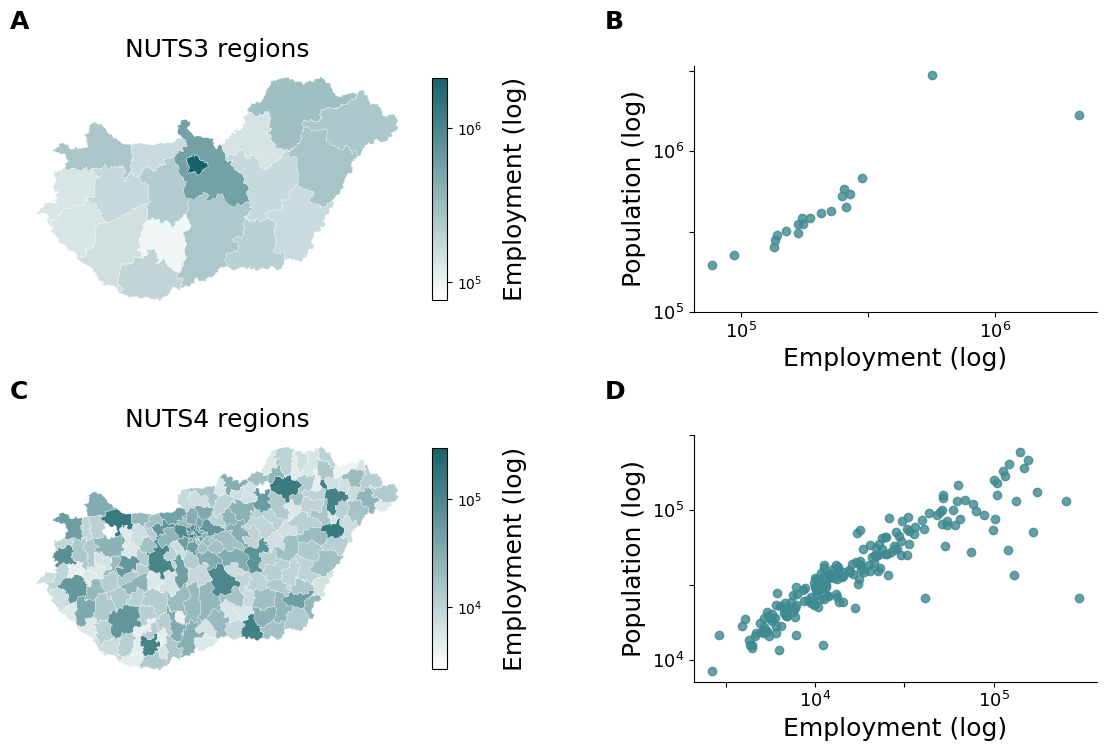

In [17]:
fig, ax = plt.subplots(2,2, figsize=(17,8), gridspec_kw={'width_ratios': [2, 1.05]})
fig.subplots_adjust(wspace=0.25, hspace=0.5)
fontsize=18

plot_map(plot_df0, key_column="log_total_emp", region_var=region_levels[0], fontsize=fontsize, cbar_text="Employment (log)", bar_positions=[5,6], bar_labels=[r'$10^5$', r'$10^6$'], shrink_value=0.9, ax=ax[0,0])
keyvar_scatter(plot_df0, key_columns=["log_total_emp", "log_pop"], xtitle="Employment (log)", ytitle="Population (log)", fontsize=fontsize, ax=ax[0,1])
ax[0,1].set_xticks([5, 5.5, 6])
ax[0,1].set_xticklabels([r'$10^5$', "", r'$10^6$'])
ax[0,1].set_yticks([5, 5.5, 6, 6.5])
ax[0,1].set_yticklabels([r'$10^5$', "", r'$10^6$', ""])

plot_map(plot_df1, key_column="log_total_emp", region_var=region_levels[1], fontsize=fontsize, cbar_text="Employment (log)", bar_positions=[4,5], bar_labels=[r'$10^4$', r'$10^5$'], shrink_value=0.9, ax=ax[1,0])
keyvar_scatter(plot_df1, key_columns=["log_total_emp", "log_pop"], xtitle="Employment (log)", ytitle="Population (log)", fontsize=fontsize, ax=ax[1,1])
ax[1,1].set_xticks([3.5, 4, 4.5, 5])
ax[1,1].set_xticklabels(["", r'$10^4$', "", r'$10^5$'])
ax[1,1].set_yticks([4, 4.5, 5, 5.5])
ax[1,1].set_yticklabels([r'$10^4$', "", r'$10^5$', ""])


# subplot title
ax[0,0].annotate("A", xy=(0,1.1), xycoords='axes fraction', xytext=(-8,12), textcoords='offset pixels', weight='bold', size=fontsize)
ax[0,1].annotate("B", xy=(-0.2,1.1), xycoords='axes fraction', xytext=(-8,12), textcoords='offset pixels', weight='bold', size=fontsize)
ax[1,0].annotate("C", xy=(0,1.1), xycoords='axes fraction', xytext=(-8,12), textcoords='offset pixels', weight='bold', size=fontsize)
ax[1,1].annotate("D", xy=(-0.2,1.1), xycoords='axes fraction', xytext=(-8,12), textcoords='offset pixels', weight='bold', size=fontsize)

# plt.savefig(f"../figures/si_map_emp_combined.png", dpi=300, bbox_inches='tight', facecolor="white")

Text(-8, 12, 'B')

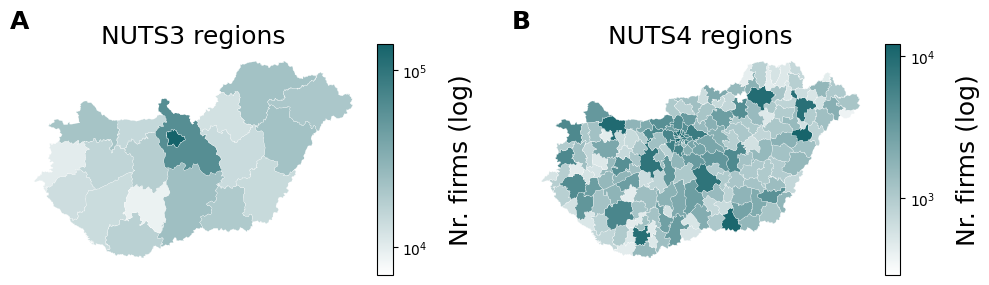

In [18]:
# map of number of firms
fig, ax = plt.subplots(1,2, figsize=(12,6))
fig.subplots_adjust(wspace=0.2)
fontsize=18

# NUTS3
#plot_df0.plot(column="log_total_firms", ax=ax[0])
plot_map(
    plot_df0,
    key_column="log_total_firms",
    region_var=region_levels[0],
    fontsize=fontsize,
    cbar_text="Nr. firms (log)",
    bar_positions=[4,5],
    bar_labels=[r'$10^4$', r'$10^5$'],
    shrink_value=0.5,
    ax=ax[0]
)

# NUTS4
#plot_df1.plot(column="log_total_firms", ax=ax[1])
plot_map(
    plot_df1,
    key_column="log_total_firms",
    region_var=region_levels[1],
    fontsize=fontsize,
    cbar_text="Nr. firms (log)",
    bar_positions=[3,4],
    bar_labels=[r'$10^3$', r'$10^4$'],
    shrink_value=0.5,
    ax=ax[1]
)

# subplot title
ax[0].annotate("A", xy=(0,1.05), xycoords='axes fraction', xytext=(-8,12), textcoords='offset pixels', weight='bold', size=fontsize)
ax[1].annotate("B", xy=(-0.015,1.05), xycoords='axes fraction', xytext=(-8,12), textcoords='offset pixels', weight='bold', size=fontsize)

# plt.savefig(f"../figures/si_map_firms.png", dpi=300, bbox_inches='tight', facecolor="white")

In [19]:
# distribution of firms / employment across industries
ind_df = pd.read_csv(f"../../data/databank_oc/industries_descriptive_final_sample_nace3d_2017.csv", sep=";")

In [20]:
# agg for visualization
ind_df["nace2d"] = ind_df["nace3d"] // 10
ind_df2 = ind_df.groupby(["nace2d"]).agg(
    total_emp = pd.NamedAgg("total_emp", "sum"),
    total_firms = pd.NamedAgg("total_firms", "sum")
).reset_index()

Text(-8, 12, 'B')

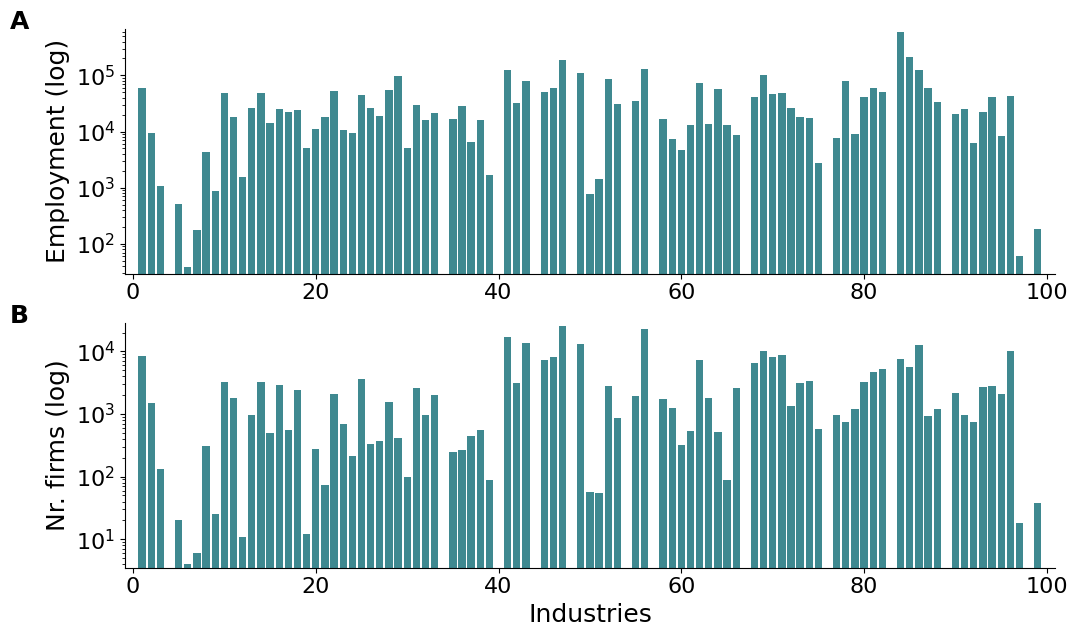

In [21]:
fig, ax = plt.subplots(2,1, figsize=(12,7))
fontsize=18

# employment
ax[0].bar(ind_df["nace2d"], ind_df["total_emp"], color="#3F8990")
ax[0].semilogy()
ax[0].set_ylabel("Employment (log)", size=fontsize)
ax[0].tick_params("x", labelsize=(fontsize-2))
ax[0].tick_params("y", labelsize=(fontsize-2))
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)
ax[0].margins(0.015, tight=True)


# firms
ax[1].bar(ind_df["nace2d"], ind_df["total_firms"], color="#3F8990")
ax[1].semilogy()
ax[1].set_xlabel("Industries", size=fontsize)
ax[1].set_ylabel("Nr. firms (log)", size=fontsize)
ax[1].tick_params("x", labelsize=(fontsize-2))
ax[1].tick_params("y", labelsize=(fontsize-2))
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)
ax[1].margins(0.015, tight=True)

# subplot title
ax[0].annotate("A", xy=(-0.115,0.95), xycoords='axes fraction', xytext=(-8,12), textcoords='offset pixels', weight='bold', size=fontsize)
ax[0].annotate("B", xy=(-0.115,-0.25), xycoords='axes fraction', xytext=(-8,12), textcoords='offset pixels', weight='bold', size=fontsize)

# plt.savefig(f"../figures/si_industries_emp_firms.png", dpi=300, bbox_inches='tight', facecolor="white")

**S2 - Key variables and alternative measures**

In [22]:
# generate colormap
cvals  = [0, 1]
colors = ["#FFFFFF","#15636A"]
norm=plt.Normalize(min(cvals),max(cvals))
tuples = list(zip(map(norm,cvals), colors))
cmap = LinearSegmentedColormap.from_list("", tuples)

In [23]:
# Mcp at different scales
def mri_matrix(df, key_columns, heatmap, cmap, labels, size, ax=None):
    table = df[key_columns]
    
    table = pd.pivot_table(table,
        values=key_columns[2],
        index=key_columns[1],
        columns=key_columns[0],
        aggfunc=np.sum,
        margins=True,
        margins_name='total')\
        .transpose()
    
    table = table\
        .sort_values(by=["total"], ascending=False, axis=0)\
        .sort_values(by=["total"], ascending=False, axis=1)

    table = table.drop(["total"], axis=1).drop(["total"], axis=0)

    if heatmap==False:
        return table
    else:
        if ax is None:
            ax = plt.gca()
        sns.heatmap(table, cbar=False, cmap=cmap, ax=ax)
        ax.set_xlabel("", size=size, labelpad=10)
        ax.set_ylabel(labels[0], size=size)
        ax.set_title(labels[1], size=size)
        ax.set_xticklabels("")
        ax.set_yticklabels("")
        ax.tick_params(left = False, bottom = False)
    

/var/folders/9d/8j37_fks51x11mk0_zwqsd940000gn/T/ipykernel_18501/907328148.py:5: FutureWarning: The provided callable <function sum at 0x1105a4220> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  table = pd.pivot_table(table,
/var/folders/9d/8j37_fks51x11mk0_zwqsd940000gn/T/ipykernel_18501/907328148.py:5: FutureWarning: The provided callable <function sum at 0x1105a4220> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  table = pd.pivot_table(table,
/var/folders/9d/8j37_fks51x11mk0_zwqsd940000gn/T/ipykernel_18501/907328148.py:5: FutureWarning: The provided callable <function sum at 0x1105a4220> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass

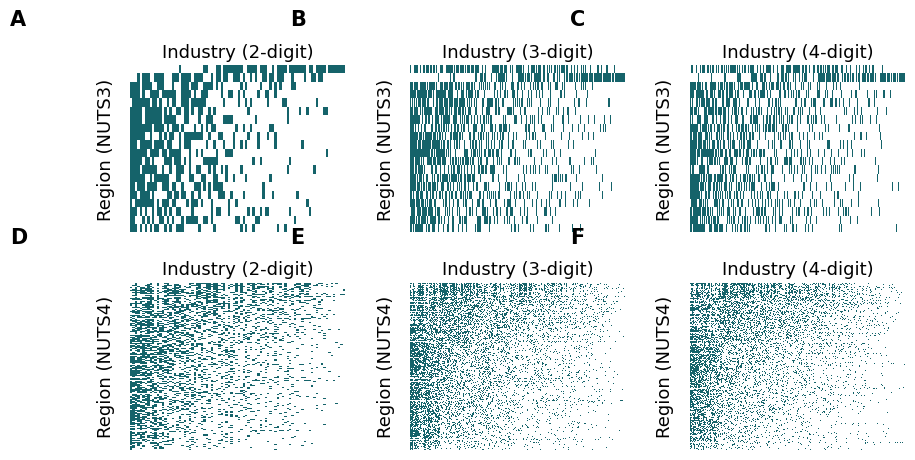

In [24]:
# data
fig, ax = plt.subplots(2,3, figsize=(10,5))
plt.subplots_adjust(wspace=0.3, hspace=0.3)
fontsize = 13

df = pd.read_csv("../../data/databank_oc/mcp_rca01_nuts3_2digits_2017.csv", sep=";")
mri_matrix(df, key_columns=["reg", "ind", "rca01"], heatmap=True, cmap=cmap, labels=["Region (NUTS3)", "Industry (2-digit)"], size=fontsize, ax=ax[0,0])

df = pd.read_csv("../../data/databank_oc/mcp_rca01_nuts3_3digits_2017.csv", sep=";")
mri_matrix(df, key_columns=["reg", "ind", "rca01"], heatmap=True, cmap=cmap, labels=["Region (NUTS3)", "Industry (3-digit)"], size=fontsize, ax=ax[0,1])

df = pd.read_csv("../../data/databank_oc/mcp_rca01_nuts3_4digits_2017.csv", sep=";")
mri_matrix(df, key_columns=["reg", "ind", "rca01"], heatmap=True, cmap=cmap, labels=["Region (NUTS3)", "Industry (4-digit)"], size=fontsize, ax=ax[0,2])

df = pd.read_csv("../../data/databank_oc/mcp_rca01_nuts4_2digits_2017.csv", sep=";")
mri_matrix(df, key_columns=["reg", "ind", "rca01"], heatmap=True, cmap=cmap, labels=["Region (NUTS4)", "Industry (2-digit)"], size=fontsize, ax=ax[1,0])

df = pd.read_csv("../../data/databank_oc/mcp_rca01_nuts4_3digits_2017.csv", sep=";")
mri_matrix(df, key_columns=["reg", "ind", "rca01"], heatmap=True, cmap=cmap, labels=["Region (NUTS4)", "Industry (3-digit)"], size=fontsize, ax=ax[1,1])

df = pd.read_csv("../../data/databank_oc/mcp_rca01_nuts4_4digits_2017.csv", sep=";")
mri_matrix(df, key_columns=["reg", "ind", "rca01"], heatmap=True, cmap=cmap, labels=["Region (NUTS4)", "Industry (4-digit)"], size=fontsize, ax=ax[1,2])

# subplot title
labels = list(string.ascii_uppercase)[:ax.size]
for i, label in enumerate(labels):
    ax.flat[i].annotate(
        label, 
        xy=(0, 1), 
        xycoords="axes fraction", 
        xytext=(-120, 40),
        #xytext=(-50, 10),
        textcoords="offset pixels", 
        weight="bold", 
        size=fontsize + 2
    )

# plt.savefig(f"../figures/si_mri_versions.png", dpi=300, bbox_inches='tight', facecolor="white")

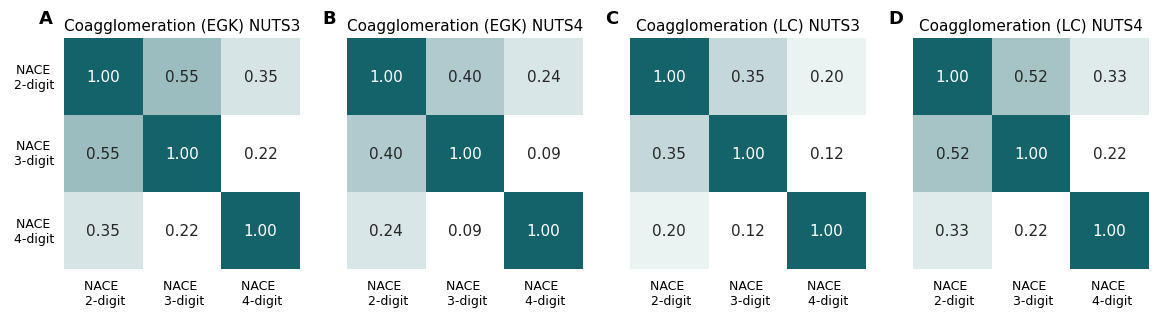

In [25]:
# make correlation matrices
fig, ax = plt.subplots(1, 4, figsize=(14,3))
plt.subplots_adjust(wspace=0.2)
fontsize = 11

custom_labels = ["NACE 2-digit", "NACE 3-digit", "NACE 4-digit"]
custom_labels2 = ["NACE \n 2-digit", "NACE \n 3-digit", "NACE \n 4-digit"]

# A
cmat = pd.read_csv("../../data/outputs/corr_egk_nuts3.csv", sep=";", index_col=0)
sns.heatmap(
    cmat,
    cbar=False,
    cmap=cmap,
    annot=True,
    annot_kws={"fontsize":(fontsize)},
    fmt=".2f",
    ax=ax[0]
)
ax[0].set_xlabel("", size=fontsize-4, labelpad=10)
ax[0].set_xticklabels(custom_labels2, size=fontsize-2, rotation=0)
ax[0].set_yticklabels(custom_labels2, size=fontsize-2, rotation=0)
ax[0].tick_params(left = False, bottom = False)
ax[0].set_title("Coagglomeration (EGK) NUTS3", size=fontsize)


# B
cmat = pd.read_csv("../../data/outputs/corr_egk_nuts4.csv", sep=";", index_col=0)
sns.heatmap(
    cmat,
    cbar=False,
    cmap=cmap,
    annot=True,
    annot_kws={"fontsize":(fontsize)},
    fmt=".2f",
    ax=ax[1]
)
ax[1].set_xlabel("", size=fontsize, labelpad=10)
ax[1].set_xticklabels(custom_labels2, size=fontsize-2, rotation=0)
ax[1].set_yticklabels("", size=fontsize-4, rotation=0)
ax[1].tick_params(left = False, bottom = False)
ax[1].set_title("Coagglomeration (EGK) NUTS4", size=fontsize)


# C
cmat = pd.read_csv("../../data/outputs/corr_coagg_porter_nuts3.csv", sep=";", index_col=0)
sns.heatmap(
    cmat,
    cbar=False,
    cmap=cmap,
    annot=True,
    annot_kws={"fontsize":(fontsize)},
    fmt=".2f",
    ax=ax[2]
)
ax[2].set_xlabel("", size=fontsize, labelpad=10)
ax[2].set_xticklabels(custom_labels2, size=fontsize-2, rotation=0)
ax[2].set_yticklabels("", size=fontsize-4, rotation=0)
ax[2].tick_params(left = False, bottom = False)
ax[2].set_title("Coagglomeration (LC) NUTS3", size=fontsize)


# D
cmat = pd.read_csv("../../data/outputs/corr_coagg_porter_nuts4.csv", sep=";", index_col=0)
sns.heatmap(
    cmat,
    cbar=False,
    cmap=cmap,
    annot=True,
    annot_kws={"fontsize":(fontsize)},
    fmt=".2f",
    ax=ax[3]
)
ax[3].set_xlabel("", size=fontsize, labelpad=10)
ax[3].set_xticklabels(custom_labels2, size=fontsize-2, rotation=0)
ax[3].set_yticklabels("", size=fontsize-4, rotation=0)
ax[3].tick_params(left = False, bottom = False)
ax[3].set_title("Coagglomeration (LC) NUTS4", size=fontsize)


# Flatten the 2D array into a 1D list
ax_flat = ax.flatten()

# Annotate each subplot
labels = list(string.ascii_uppercase)[:len(ax_flat)]
for i, label in enumerate(labels):
    ax_flat[i].annotate(
        label, 
        xy=(0, 1), 
        xycoords="axes fraction", 
        xytext=(-25, 15),
        #xytext=(-80, 40),
        textcoords="offset pixels", 
        weight="bold", 
        size=fontsize + 2
    )

#plt.savefig(f"../figures/si_coagglomeration_nace_level_region_level_correlations.png", dpi=300, bbox_inches='tight', facecolor="white")

In [26]:
def matrix_represantation(df, key_columns, sort_matrix, heatmap, fontsize, title_text, cmap, cbar_label, ax=None):
    """matrix or pivot table representation of our key variables"""
    table = df[key_columns]

    # undirected to directed -- to have a full matrix
    table2 = table.copy().rename(columns={"ind1": "ind2", "ind2": "ind1"})
    table2 = table2[key_columns]
    table = pd.concat([table, table2])

    # pivot transformation
    table = pd.pivot_table(table,
        values=key_columns[2],
        index=key_columns[0],
        columns=key_columns[1],
        aggfunc=np.max,
        margins=True,
        margins_name='total')

    # option to sort the matrix
    if sort_matrix == True:
        table = table\
            .sort_values(by=["total"], ascending=False, axis=0)\
            .sort_values(by=["total"], ascending=False, axis=1)
    else:
        table = table
    
    table = table.drop(["total"], axis=1).drop(["total"], axis=0)
    
    # option to keep the table or create heatmap
    if heatmap==False:
        return table
    else:
        if ax is None:
            ax = plt.gca()
        sns.heatmap(
            table,
            cbar=True,
            cmap=cmap,
            ax=ax
        )
        ax.figure.axes[-1].set_ylabel(cbar_label, size=fontsize-5)
        ax.set_xlabel("Industry", size=fontsize)
        ax.set_ylabel("Industry", size=fontsize)
        ax.set_title(title_text, size=fontsize)
        ax.yaxis.set_tick_params(rotation=0, labelbottom=True)
        #ax.set_xticklabels("")
        #ax.set_yticklabels("")
        ax.tick_params(left = False, bottom = False)

In [27]:
# KDE plots to illustrate distribution
def density_plot(df, key_column, colorway, xlabel_text, fontsize, ax=None):
    if ax is None:
        ax = plt.gca()

    sns.kdeplot(data=df,
        x=key_column,
        fill=True,
        color=colorway,
        linewidth=2.5,
        log_scale=False,
        ax=ax)
    
    ax.set_xlabel(xlabel_text, size=fontsize)
    ax.set_ylabel("Density", size=fontsize)
    ax.tick_params("x", labelsize=(fontsize-5))
    ax.tick_params("y", labelsize=(fontsize-5))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

/var/folders/9d/8j37_fks51x11mk0_zwqsd940000gn/T/ipykernel_18501/853034764.py:11: FutureWarning: The provided callable <function max at 0x1105a5120> is currently using DataFrameGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  table = pd.pivot_table(table,
/var/folders/9d/8j37_fks51x11mk0_zwqsd940000gn/T/ipykernel_18501/853034764.py:11: FutureWarning: The provided callable <function max at 0x1105a5120> is currently using DataFrameGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  table = pd.pivot_table(table,
/var/folders/9d/8j37_fks51x11mk0_zwqsd940000gn/T/ipykernel_18501/853034764.py:11: FutureWarning: The provided callable <function max at 0x1105a5120> is currently using DataFrameGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior p

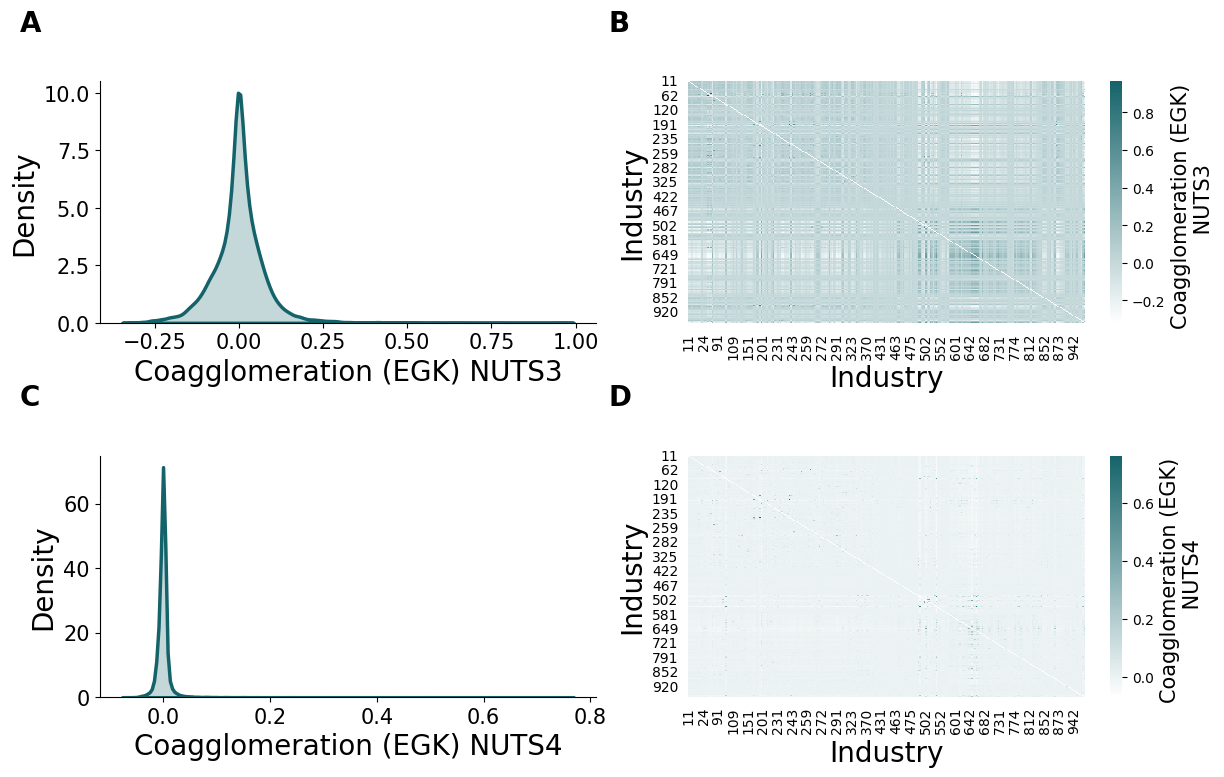

In [28]:
fig = plt.figure(figsize=(14, 8))
ax = [0]*4
gs = GridSpec(2,2, figure=fig)
ax[0] = fig.add_subplot(gs[0,0])
ax[1] = fig.add_subplot(gs[0,1])
ax[2] = fig.add_subplot(gs[1,0])
ax[3] = fig.add_subplot(gs[1,1])
fig.subplots_adjust(hspace=0.55, wspace=0.185) 

textsize = 20
key_var = "egk_coagg"
region_levels = ["nuts3", "nuts4"]

# NUST3
reg_df = pd.read_csv(f"../../data/databank_oc/04oc_data_{region_levels[0]}_{year}.csv", sep=";")
reg_df = reg_df[reg_df["ind1"] < reg_df["ind2"]]

# colormap
cvals  = [reg_df[key_var].min(), reg_df[key_var].max()]
colors = ["#FFFFFF","#15636A"]
norm=plt.Normalize(min(cvals),max(cvals))
tuples = list(zip(map(norm,cvals), colors))
cmap = LinearSegmentedColormap.from_list("", tuples)

density_plot(
    reg_df,
    key_column=key_var,
    colorway=colors[1],
    xlabel_text="Coagglomeration (EGK) NUTS3",
    fontsize=textsize,
    ax=ax[0]
)

matrix_represantation(
    reg_df,
    key_columns=["ind1", "ind2", key_var],
    sort_matrix=False,
    heatmap=True,
    fontsize=textsize,
    title_text="",
    cmap=cmap,
    cbar_label="Coagglomeration (EGK) \n NUTS3",
    ax=ax[1]
)

# NUTS4
reg_df = pd.read_csv(f"../../data/databank_oc/04oc_data_{region_levels[1]}_{year}.csv", sep=";")
reg_df = reg_df[reg_df["ind1"] < reg_df["ind2"]]

# colormap
cvals  = [reg_df[key_var].min(), reg_df[key_var].max()]
colors = ["#FFFFFF","#15636A"]
norm=plt.Normalize(min(cvals),max(cvals))
tuples = list(zip(map(norm,cvals), colors))
cmap = LinearSegmentedColormap.from_list("", tuples)

density_plot(
    reg_df,
    key_column=key_var,
    colorway=colors[1],
    xlabel_text="Coagglomeration (EGK) NUTS4",
    fontsize=textsize,
    ax=ax[2]
)

matrix_represantation(
    reg_df,
    key_columns=["ind1", "ind2", key_var],
    sort_matrix=False,
    heatmap=True,
    fontsize=textsize,
    title_text="",
    cmap=cmap,
    cbar_label="Coagglomeration (EGK) \n NUTS4",
    ax=ax[3]
)

# subplot title
for a, label in zip(ax, ['A','B','C','D']):
    a.annotate(label.upper(), xy=(0,1), xycoords='axes fraction', xytext=(-80,50), textcoords='offset pixels', weight='bold', size=textsize)

# plt.savefig(f"../figures/si_{key_var}_distributions.png", dpi=300, bbox_inches='tight', facecolor="white")

/var/folders/9d/8j37_fks51x11mk0_zwqsd940000gn/T/ipykernel_18501/853034764.py:11: FutureWarning: The provided callable <function max at 0x1105a5120> is currently using DataFrameGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  table = pd.pivot_table(table,
/var/folders/9d/8j37_fks51x11mk0_zwqsd940000gn/T/ipykernel_18501/853034764.py:11: FutureWarning: The provided callable <function max at 0x1105a5120> is currently using DataFrameGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  table = pd.pivot_table(table,
/var/folders/9d/8j37_fks51x11mk0_zwqsd940000gn/T/ipykernel_18501/853034764.py:11: FutureWarning: The provided callable <function max at 0x1105a5120> is currently using DataFrameGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior p

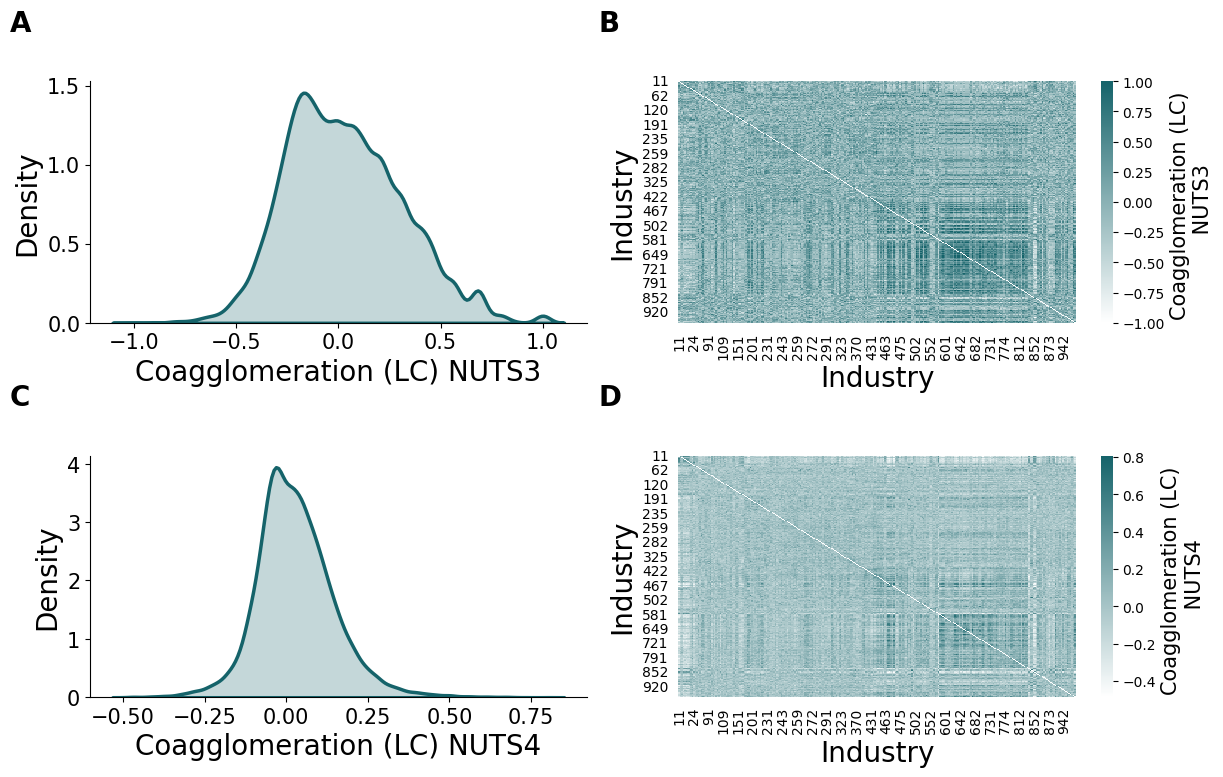

In [29]:
fig = plt.figure(figsize=(14, 8))
ax = [0]*4
gs = GridSpec(2,2, figure=fig)
ax[0] = fig.add_subplot(gs[0,0])
ax[1] = fig.add_subplot(gs[0,1])
ax[2] = fig.add_subplot(gs[1,0])
ax[3] = fig.add_subplot(gs[1,1])
fig.subplots_adjust(hspace=0.55, wspace=0.185) 

textsize = 20
key_var = "coagg_porter_rca01"
region_levels = ["nuts3", "nuts4"]

# colormap
cvals  = [reg_df[key_var].min(), reg_df[key_var].max()]
colors = ["#FFFFFF","#15636A"]
norm=plt.Normalize(min(cvals),max(cvals))
tuples = list(zip(map(norm,cvals), colors))
cmap = LinearSegmentedColormap.from_list("", tuples)

# NUST3
reg_df = pd.read_csv(f"../../data/databank_oc/04oc_data_{region_levels[0]}_{year}.csv", sep=";")
reg_df = reg_df[reg_df["ind1"] < reg_df["ind2"]]

density_plot(
    reg_df,
    key_column=key_var,
    colorway=colors[1],
    xlabel_text="Coagglomeration (LC) NUTS3",
    fontsize=textsize,
    ax=ax[0]
)

matrix_represantation(
    reg_df,
    key_columns=["ind1", "ind2", key_var],
    sort_matrix=False,
    heatmap=True,
    fontsize=textsize,
    title_text="",
    cmap=cmap,
    cbar_label="Coagglomeration (LC) \n NUTS3",
    ax=ax[1]
)


# NUTS4
reg_df = pd.read_csv(f"../../data/databank_oc/04oc_data_{region_levels[1]}_{year}.csv", sep=";")
reg_df = reg_df[reg_df["ind1"] < reg_df["ind2"]]

density_plot(
    reg_df,
    key_column=key_var,
    colorway=colors[1],
    xlabel_text="Coagglomeration (LC) NUTS4",
    fontsize=textsize,
    ax=ax[2]
)

matrix_represantation(
    reg_df,
    key_columns=["ind1", "ind2", key_var],
    sort_matrix=False,
    heatmap=True,
    fontsize=textsize,
    title_text="",
    cmap=cmap,
    cbar_label="Coagglomeration (LC) \n NUTS4",
    ax=ax[3]
)

# subplot title
for a, label in zip(ax, ['A','B','C','D']):
    a.annotate(label.upper(), xy=(0,1), xycoords='axes fraction', xytext=(-80,50), textcoords='offset pixels', weight='bold', size=textsize)

# plt.savefig(f"../figures/si_{key_var}_distributions.png", dpi=300, bbox_inches='tight', facecolor="white")

/var/folders/9d/8j37_fks51x11mk0_zwqsd940000gn/T/ipykernel_18501/853034764.py:11: FutureWarning: The provided callable <function max at 0x1105a5120> is currently using DataFrameGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  table = pd.pivot_table(table,
/var/folders/9d/8j37_fks51x11mk0_zwqsd940000gn/T/ipykernel_18501/853034764.py:11: FutureWarning: The provided callable <function max at 0x1105a5120> is currently using DataFrameGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  table = pd.pivot_table(table,
/var/folders/9d/8j37_fks51x11mk0_zwqsd940000gn/T/ipykernel_18501/853034764.py:11: FutureWarning: The provided callable <function max at 0x1105a5120> is currently using DataFrameGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior p

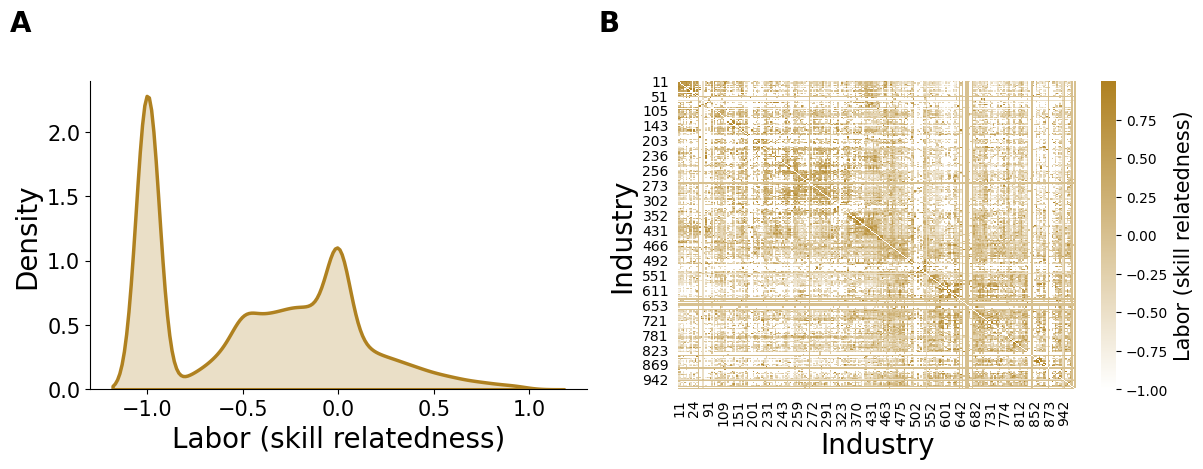

In [30]:
fig = plt.figure(figsize=(14, 4))
ax = [0]*2
gs = GridSpec(1,2, figure=fig)
ax[0] = fig.add_subplot(gs[0,0])
ax[1] = fig.add_subplot(gs[0,1])
fig.subplots_adjust(hspace=0.55, wspace=0.185) 

textsize = 20
key_var = "sr_norm"
region_levels = ["nuts3", "nuts4"]

# colormap
cvals  = [-1, 1]
colors = ["#FFFFFF","#AF8120"]
norm=plt.Normalize(min(cvals),max(cvals))
tuples = list(zip(map(norm,cvals), colors))
cmap = LinearSegmentedColormap.from_list("", tuples)

# NUST3
reg_df = pd.read_csv(f"../../data/databank_oc/04oc_data_{region_levels[0]}_{year}.csv", sep=";")
reg_df = reg_df[reg_df["ind1"] < reg_df["ind2"]]

density_plot(
    reg_df,
    key_column=key_var,
    colorway=colors[1],
    xlabel_text="Labor (skill relatedness)",
    fontsize=textsize,
    ax=ax[0]
)

matrix_represantation(
    reg_df,
    key_columns=["ind1", "ind2", key_var],
    sort_matrix=False,
    heatmap=True,
    fontsize=textsize,
    title_text="",
    cmap=cmap,
    cbar_label="Labor (skill relatedness)",
    ax=ax[1]
)

# subplot title
for a, label in zip(ax, ['A','B','C','D']):
    a.annotate(label.upper(), xy=(0,1), xycoords='axes fraction', xytext=(-80,50), textcoords='offset pixels', weight='bold', size=textsize)

# plt.savefig(f"../figures/si_{key_var}_distributions.png", dpi=300, bbox_inches='tight', facecolor="white")

/var/folders/9d/8j37_fks51x11mk0_zwqsd940000gn/T/ipykernel_18501/853034764.py:11: FutureWarning: The provided callable <function max at 0x1105a5120> is currently using DataFrameGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  table = pd.pivot_table(table,
/var/folders/9d/8j37_fks51x11mk0_zwqsd940000gn/T/ipykernel_18501/853034764.py:11: FutureWarning: The provided callable <function max at 0x1105a5120> is currently using DataFrameGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  table = pd.pivot_table(table,
/var/folders/9d/8j37_fks51x11mk0_zwqsd940000gn/T/ipykernel_18501/853034764.py:11: FutureWarning: The provided callable <function max at 0x1105a5120> is currently using DataFrameGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior p

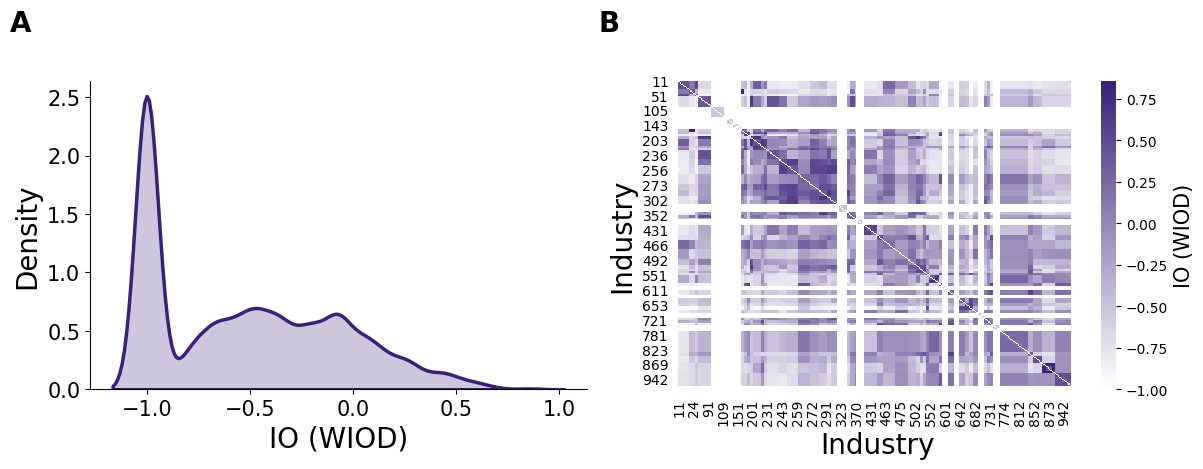

In [31]:
fig = plt.figure(figsize=(14, 4))
ax = [0]*2
gs = GridSpec(1,2, figure=fig)
ax[0] = fig.add_subplot(gs[0,0])
ax[1] = fig.add_subplot(gs[0,1])
fig.subplots_adjust(hspace=0.55, wspace=0.185) 

textsize = 20
key_var = "io_wiot_hun"
region_levels = ["nuts3", "nuts4"]

# colormap
cvals  = [-1, 1]
colors = ["#FFFFFF","#382178"]
norm=plt.Normalize(min(cvals),max(cvals))
tuples = list(zip(map(norm,cvals), colors))
cmap = LinearSegmentedColormap.from_list("", tuples)

# NUST3
reg_df = pd.read_csv(f"../../data/databank_oc/04oc_data_{region_levels[0]}_{year}.csv", sep=";")
reg_df = reg_df[reg_df["ind1"] < reg_df["ind2"]]

density_plot(
    reg_df,
    key_column=key_var,
    colorway=colors[1],
    xlabel_text="IO (WIOD)",
    fontsize=textsize,
    ax=ax[0]
)

matrix_represantation(
    reg_df,
    key_columns=["ind1", "ind2", key_var],
    sort_matrix=False,
    heatmap=True,
    fontsize=textsize,
    title_text="",
    cmap=cmap,
    cbar_label="IO (WIOD)",
    ax=ax[1]
)

# subplot title
for a, label in zip(ax, ['A','B','C','D']):
    a.annotate(label.upper(), xy=(0,1), xycoords='axes fraction', xytext=(-80,50), textcoords='offset pixels', weight='bold', size=textsize)

# plt.savefig(f"../figures/si_{key_var}_distributions.png", dpi=300, bbox_inches='tight', facecolor="white")

/var/folders/9d/8j37_fks51x11mk0_zwqsd940000gn/T/ipykernel_18501/853034764.py:11: FutureWarning: The provided callable <function max at 0x1105a5120> is currently using DataFrameGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  table = pd.pivot_table(table,
/var/folders/9d/8j37_fks51x11mk0_zwqsd940000gn/T/ipykernel_18501/853034764.py:11: FutureWarning: The provided callable <function max at 0x1105a5120> is currently using DataFrameGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  table = pd.pivot_table(table,
/var/folders/9d/8j37_fks51x11mk0_zwqsd940000gn/T/ipykernel_18501/853034764.py:11: FutureWarning: The provided callable <function max at 0x1105a5120> is currently using DataFrameGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior p

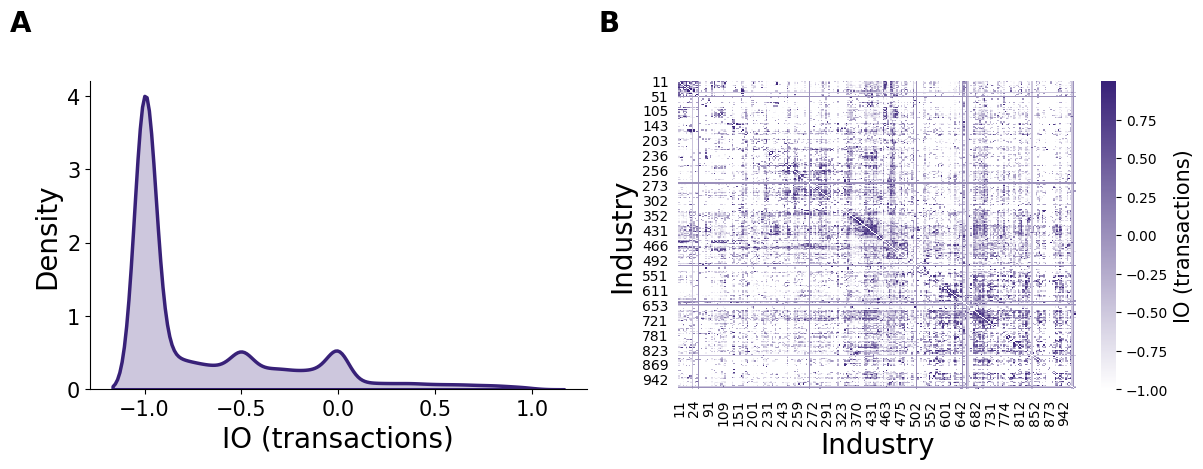

In [32]:
fig = plt.figure(figsize=(14, 4))
ax = [0]*2
gs = GridSpec(1,2, figure=fig)
ax[0] = fig.add_subplot(gs[0,0])
ax[1] = fig.add_subplot(gs[0,1])
fig.subplots_adjust(hspace=0.55, wspace=0.185) 

textsize = 20
key_var = "io_norm3"
region_levels = ["nuts3", "nuts4"]

# colormap
cvals  = [-1, 1]
colors = ["#FFFFFF","#382178"]
norm=plt.Normalize(min(cvals),max(cvals))
tuples = list(zip(map(norm,cvals), colors))
cmap = LinearSegmentedColormap.from_list("", tuples)

# NUST3
reg_df = pd.read_csv(f"../../data/databank_oc/04oc_data_{region_levels[0]}_{year}.csv", sep=";")
reg_df = reg_df[reg_df["ind1"] < reg_df["ind2"]]

density_plot(
    reg_df,
    key_column=key_var,
    colorway=colors[1],
    xlabel_text="IO (transactions)",
    fontsize=textsize,
    ax=ax[0]
)

matrix_represantation(
    reg_df,
    key_columns=["ind1", "ind2", key_var],
    sort_matrix=False,
    heatmap=True,
    fontsize=textsize,
    title_text="",
    cmap=cmap,
    cbar_label="IO (transactions)",
    ax=ax[1]
)

# subplot title
for a, label in zip(ax, ['A','B','C','D']):
    a.annotate(label.upper(), xy=(0,1), xycoords='axes fraction', xytext=(-80,50), textcoords='offset pixels', weight='bold', size=textsize)

# plt.savefig(f"../figures/si_{key_var}_distributions.png", dpi=300, bbox_inches='tight', facecolor="white")

/var/folders/9d/8j37_fks51x11mk0_zwqsd940000gn/T/ipykernel_18501/853034764.py:11: FutureWarning: The provided callable <function max at 0x1105a5120> is currently using DataFrameGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  table = pd.pivot_table(table,
/var/folders/9d/8j37_fks51x11mk0_zwqsd940000gn/T/ipykernel_18501/853034764.py:11: FutureWarning: The provided callable <function max at 0x1105a5120> is currently using DataFrameGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  table = pd.pivot_table(table,
/var/folders/9d/8j37_fks51x11mk0_zwqsd940000gn/T/ipykernel_18501/853034764.py:11: FutureWarning: The provided callable <function max at 0x1105a5120> is currently using DataFrameGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior p

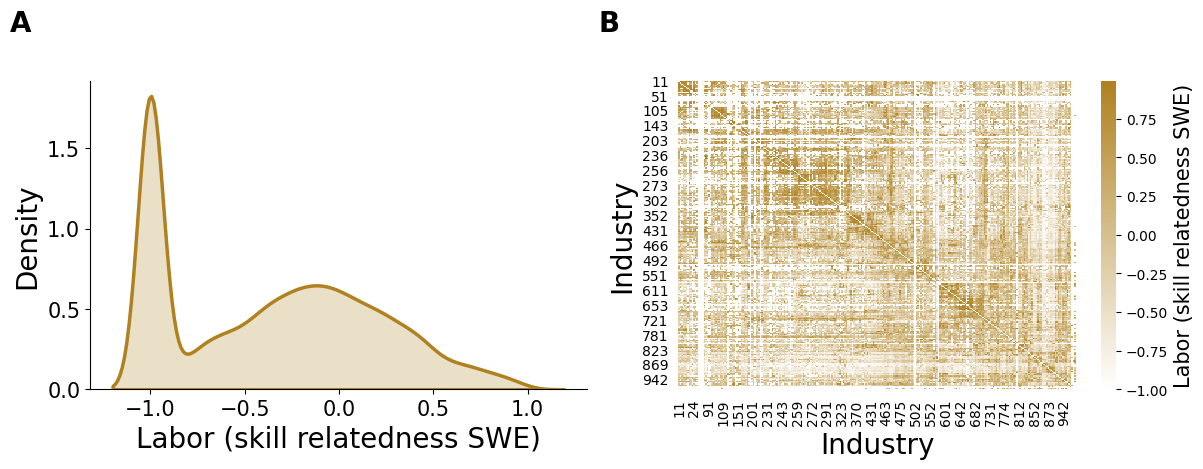

In [33]:
fig = plt.figure(figsize=(14, 4))
ax = [0]*2
gs = GridSpec(1,2, figure=fig)
ax[0] = fig.add_subplot(gs[0,0])
ax[1] = fig.add_subplot(gs[0,1])
fig.subplots_adjust(hspace=0.55, wspace=0.185) 

textsize = 20
key_var = "swe_sr_norm"
region_levels = ["nuts3", "nuts4"]

# colormap
cvals  = [-1, 1]
colors = ["#FFFFFF","#AF8120"]
norm=plt.Normalize(min(cvals),max(cvals))
tuples = list(zip(map(norm,cvals), colors))
cmap = LinearSegmentedColormap.from_list("", tuples)

# NUST3
reg_df = pd.read_csv(f"../../data/databank_oc/04oc_data_{region_levels[0]}_{year}.csv", sep=";")
reg_df = reg_df[reg_df["ind1"] < reg_df["ind2"]]

density_plot(
    reg_df,
    key_column=key_var,
    colorway=colors[1],
    xlabel_text="Labor (skill relatedness SWE)",
    fontsize=textsize,
    ax=ax[0]
)

matrix_represantation(
    reg_df,
    key_columns=["ind1", "ind2", key_var],
    sort_matrix=False,
    heatmap=True,
    fontsize=textsize,
    title_text="",
    cmap=cmap,
    cbar_label="Labor (skill relatedness SWE)",
    ax=ax[1]
)

# subplot title
for a, label in zip(ax, ['A','B','C','D']):
    a.annotate(label.upper(), xy=(0,1), xycoords='axes fraction', xytext=(-80,50), textcoords='offset pixels', weight='bold', size=textsize)

# plt.savefig(f"../figures/si_{key_var}_distributions.png", dpi=300, bbox_inches='tight', facecolor="white")

/var/folders/9d/8j37_fks51x11mk0_zwqsd940000gn/T/ipykernel_18501/853034764.py:11: FutureWarning: The provided callable <function max at 0x1105a5120> is currently using DataFrameGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  table = pd.pivot_table(table,
/var/folders/9d/8j37_fks51x11mk0_zwqsd940000gn/T/ipykernel_18501/853034764.py:11: FutureWarning: The provided callable <function max at 0x1105a5120> is currently using DataFrameGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  table = pd.pivot_table(table,
/var/folders/9d/8j37_fks51x11mk0_zwqsd940000gn/T/ipykernel_18501/853034764.py:11: FutureWarning: The provided callable <function max at 0x1105a5120> is currently using DataFrameGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior p

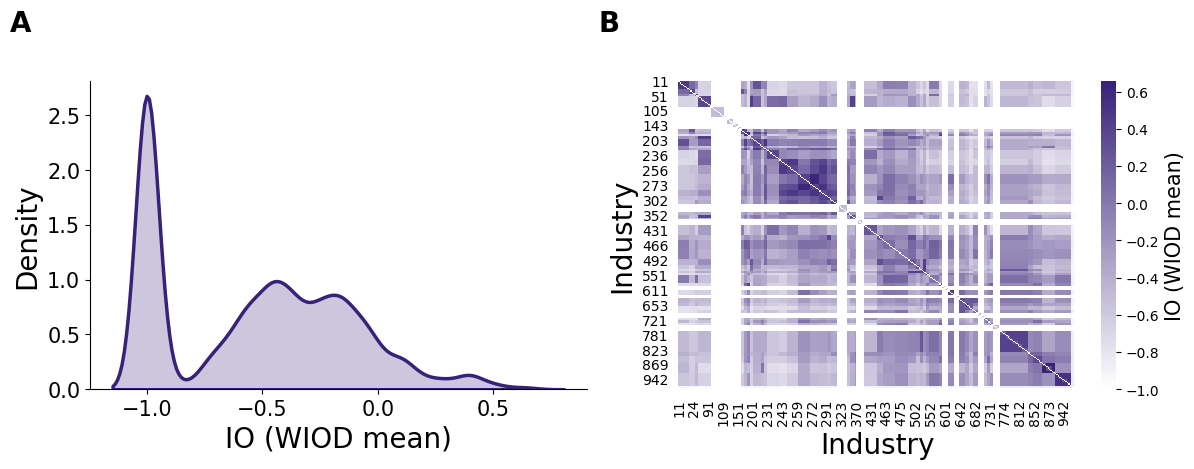

In [34]:
fig = plt.figure(figsize=(14, 4))
ax = [0]*2
gs = GridSpec(1,2, figure=fig)
ax[0] = fig.add_subplot(gs[0,0])
ax[1] = fig.add_subplot(gs[0,1])
fig.subplots_adjust(hspace=0.55, wspace=0.185) 

textsize = 20
key_var = "iv_wiot_mean"
region_levels = ["nuts3", "nuts4"]

# colormap
cvals  = [-1, 1]
colors = ["#FFFFFF","#382178"]
norm=plt.Normalize(min(cvals),max(cvals))
tuples = list(zip(map(norm,cvals), colors))
cmap = LinearSegmentedColormap.from_list("", tuples)

# NUST3
reg_df = pd.read_csv(f"../../data/databank_oc/04oc_data_{region_levels[0]}_{year}.csv", sep=";")
reg_df = reg_df[reg_df["ind1"] < reg_df["ind2"]]

density_plot(
    reg_df,
    key_column=key_var,
    colorway=colors[1],
    xlabel_text="IO (WIOD mean)",
    fontsize=textsize,
    ax=ax[0]
)

matrix_represantation(
    reg_df,
    key_columns=["ind1", "ind2", key_var],
    sort_matrix=False,
    heatmap=True,
    fontsize=textsize,
    title_text="",
    cmap=cmap,
    cbar_label="IO (WIOD mean)",
    ax=ax[1]
)

# subplot title
for a, label in zip(ax, ['A','B','C','D']):
    a.annotate(label.upper(), xy=(0,1), xycoords='axes fraction', xytext=(-80,50), textcoords='offset pixels', weight='bold', size=textsize)

# plt.savefig(f"../figures/si_{key_var}_distributions.png", dpi=300, bbox_inches='tight', facecolor="white")

In [35]:
def correlation_matrix(data, key_columns, labels, textsize, cmap, heatmap=True, ax=None):
    """create heatmap from correlation matrix"""
    
    # only important columns
    data = data[key_columns]

    # correlation matrix
    corr_mat = round(data.corr(), 2)

    if heatmap==False:
        return corr_mat
    else:
        if ax is None:
            ax = plt.gca()
        sns.heatmap(corr_mat, cbar=False, annot=True, cmap=cmap, ax=ax)
        ax.set_xticklabels(labels, size=textsize)
        ax.set_yticklabels(labels, size=textsize)

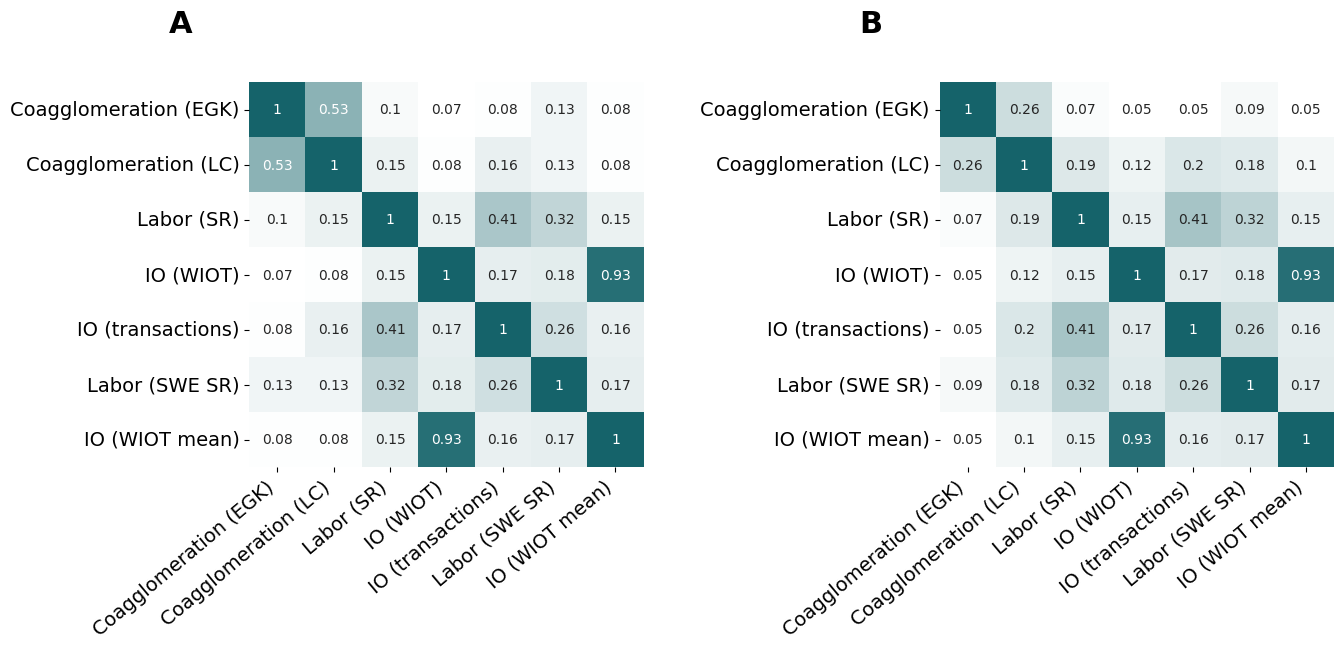

In [36]:
# correlation table
fig = plt.figure(figsize=(14, 5))
ax = [0]*2
gs = GridSpec(1,2, figure=fig)
ax[0] = fig.add_subplot(gs[0,0])
ax[1] = fig.add_subplot(gs[0,1])
fig.subplots_adjust(wspace=0.75) 

textsize = 14
key_vars = ["egk_coagg", "coagg_porter_rca01", "sr_norm", "io_norm3", "io_wiot_hun", "swe_sr_norm", "iv_wiot_mean"]
region_levels = ["nuts3", "nuts4"]

# colormap
cvals  = [0, 1]
colors = ["#FFFFFF","#15636A"]
norm=plt.Normalize(min(cvals),max(cvals))
tuples = list(zip(map(norm,cvals), colors))
cmap = LinearSegmentedColormap.from_list("", tuples)

# NUST3
reg_df = pd.read_csv(f"../../data/databank_oc/04oc_data_{region_levels[0]}_{year}.csv", sep=";")
reg_df = reg_df[reg_df["ind1"] < reg_df["ind2"]]
reg_df = reg_df[key_vars]

# plot the matrix w/ style
corr_mat = reg_df.corr()

labels = ["Coagglomeration (EGK)", "Coagglomeration (LC)", "Labor (SR)", "IO (WIOT)", "IO (transactions)", "Labor (SWE SR)", "IO (WIOT mean)"]
correlation_matrix(
    reg_df,
    key_columns=["egk_coagg", "coagg_porter_rca01", "sr_norm", "io_wiot_hun", "io_norm3", "swe_sr_norm", "iv_wiot_mean"],
    labels=labels,
    textsize=textsize,
    cmap=cmap,
    heatmap=True,
    ax=ax[0]
)
ax[0].set_xticklabels(labels, size=textsize, rotation=40, ha='right')

# NUST4
reg_df = pd.read_csv(f"../../data/databank_oc/04oc_data_{region_levels[1]}_{year}.csv", sep=";")
reg_df = reg_df[reg_df["ind1"] < reg_df["ind2"]]
reg_df = reg_df[key_vars]

# plot the matrix w/ style
corr_mat = reg_df.corr()

labels = ["Coagglomeration (EGK)", "Coagglomeration (LC)", "Labor (SR)", "IO (WIOT)", "IO (transactions)", "Labor (SWE SR)", "IO (WIOT mean)"]
correlation_matrix(
    reg_df,
    key_columns=["egk_coagg", "coagg_porter_rca01", "sr_norm", "io_wiot_hun", "io_norm3", "swe_sr_norm", "iv_wiot_mean"],
    labels=labels,
    textsize=textsize,
    cmap=cmap,
    heatmap=True,
    ax=ax[1]
)
ax[1].set_xticklabels(labels, size=textsize, rotation=40, ha='right')

# subplot title
for a, label in zip(ax, ['A','B','C','D']):
    a.annotate(label.upper(), xy=(0,1), xycoords='axes fraction', xytext=(-80,50), textcoords='offset pixels', weight='bold', size=textsize+8)

# plt.savefig(f"../figures/si_corr_matrix.png", dpi=300, bbox_inches='tight', facecolor="white")

**S3 - Results considering knowledge spillovers through patent data**

In [37]:
# citation based relatedness of 2-digit industries -- constructed in 06_revision.R
cr_table = pd.read_csv("../../data/outputs/cr_norm_citation.csv", sep=";")
cr_table.rename(columns={"ind_i":"ind1", "ind_j":"ind2"}, inplace=True)
cr_table = cr_table[cr_table["ind1"] < cr_table["ind2"]]

/var/folders/9d/8j37_fks51x11mk0_zwqsd940000gn/T/ipykernel_18501/853034764.py:11: FutureWarning: The provided callable <function max at 0x1105a5120> is currently using DataFrameGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  table = pd.pivot_table(table,
/var/folders/9d/8j37_fks51x11mk0_zwqsd940000gn/T/ipykernel_18501/853034764.py:11: FutureWarning: The provided callable <function max at 0x1105a5120> is currently using DataFrameGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  table = pd.pivot_table(table,
/var/folders/9d/8j37_fks51x11mk0_zwqsd940000gn/T/ipykernel_18501/853034764.py:11: FutureWarning: The provided callable <function max at 0x1105a5120> is currently using DataFrameGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior p

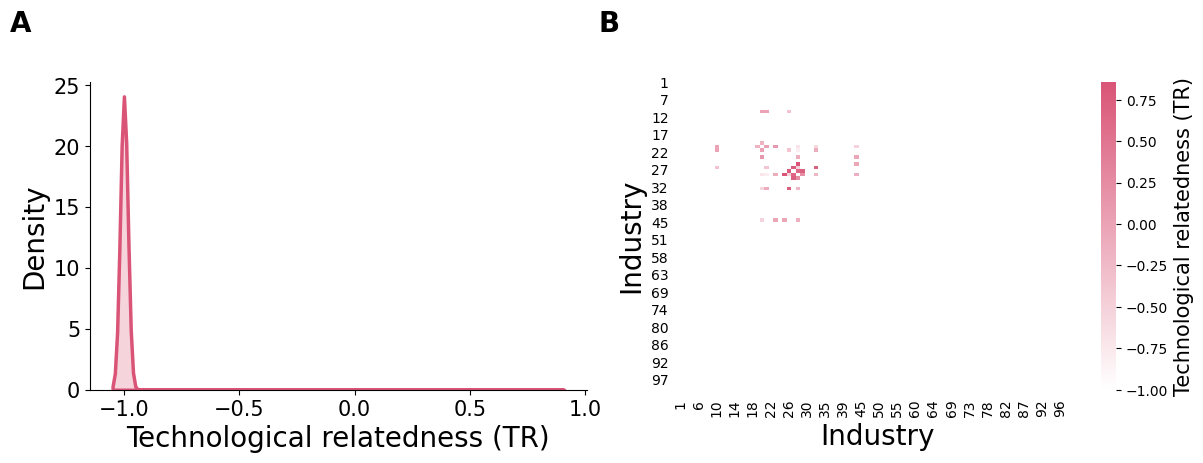

In [38]:
fig = plt.figure(figsize=(14, 4))
ax = [0]*2
gs = GridSpec(1,2, figure=fig)
ax[0] = fig.add_subplot(gs[0,0])
ax[1] = fig.add_subplot(gs[0,1])
fig.subplots_adjust(hspace=0.55, wspace=0.185) 

textsize = 20
key_var = "cr_norm"

# colormap
cvals  = [-1, 1]
colors = ["#FFFFFF","#D95476"]
norm=plt.Normalize(min(cvals),max(cvals))
tuples = list(zip(map(norm,cvals), colors))
cmap = LinearSegmentedColormap.from_list("", tuples)

density_plot(
    cr_table,
    key_column=key_var,
    colorway=colors[1],
    xlabel_text="Technological relatedness (TR)",
    fontsize=textsize,
    ax=ax[0]
)

matrix_represantation(
    cr_table,
    key_columns=["ind1", "ind2", key_var],
    sort_matrix=False,
    heatmap=True,
    fontsize=textsize,
    title_text="",
    cmap=cmap,
    cbar_label="Technological relatedness (TR)",
    ax=ax[1]
)
ax[1].xaxis.set_tick_params(rotation=90, labelbottom=True)

# subplot title
for a, label in zip(ax, ['A','B','C','D']):
    a.annotate(label.upper(), xy=(0,1), xycoords='axes fraction', xytext=(-80,50), textcoords='offset pixels', weight='bold', size=textsize)

# plt.savefig(f"../figures/revision_technology_distribution.png", dpi=300, bbox_inches='tight', facecolor="white")

In [39]:
# data from /code/95b_regressions_main.R
mf_df = pd.read_csv("../../data/outputs/marginal_effects_for_interplots_with_citations.csv", sep=";")

In [40]:
def custom_interplot(df, setting_vector, fontsize, ax=None):
    df = df[(df["dep_var"]==setting_vector[0]) & (df["y_values"]==setting_vector[1]) & (df["x_var"]==setting_vector[2])]
    
    if ax is None: 
        ax = plt.gca()
    ax.plot(df["x_values"], df["AME"], color="black", zorder=4)
    ax.plot(df["x_values"], df["upper"], color="#15636A", zorder=4)
    ax.plot(df["x_values"], df["lower"], color="#15636A", zorder=4)
    ax.fill_between(df["x_values"], df["lower"], df["upper"], color="#15636A", alpha=0.3, zorder=3)
    ax.axhline(y=0, color='black', linestyle='--', zorder=2)
    ax.tick_params("x", labelsize=(fontsize-5))
    ax.tick_params("y", labelsize=(fontsize-5))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

Text(-125, 75, 'H')

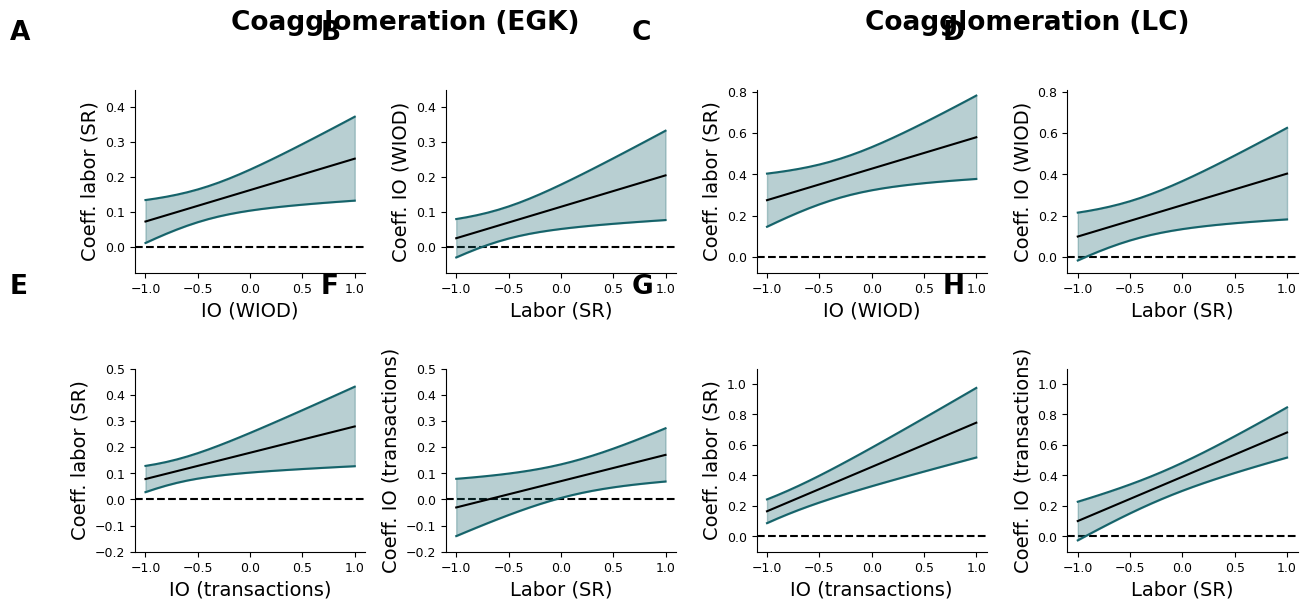

In [41]:
fig, ax = plt.subplots(2,4, figsize=(15, 6))
plt.subplots_adjust(wspace=0.35, hspace=0.525)
fontsize=14


title_text = "Coagglomeration (EGK)"
fig.text((ax[0, 0].get_position().x0 + ax[0, 1].get_position().x1) / 2, 
         ax[0, 0].get_position().y1 + 0.1,
         title_text, ha="center", weight="bold", fontsize=fontsize+5)
title_text = "Coagglomeration (LC)"
fig.text((ax[0, 2].get_position().x0 + ax[0, 3].get_position().x1) / 2, 
         ax[0, 2].get_position().y1 + 0.1,
         title_text, ha="center", weight="bold", fontsize=fontsize+5)


custom_interplot(mf_df, setting_vector=["egk_coagg_stand_nuts4", "sr_norm", "io_wiot_hun"], fontsize=fontsize, ax=ax[0,0])
ax[0,0].set_ylim(-0.075, 0.45)
ax[0,0].set_ylabel("Coeff. labor (SR)", size=fontsize)
ax[0,0].set_xlabel("IO (WIOD)", size=fontsize)

custom_interplot(mf_df, setting_vector=["egk_coagg_stand_nuts4", "io_wiot_hun", "sr_norm"], fontsize=fontsize, ax=ax[0,1])
ax[0,1].set_ylim(-0.075, 0.45)
ax[0,1].set_ylabel("Coeff. IO (WIOD)", size=fontsize)
ax[0,1].set_xlabel("Labor (SR)", size=fontsize)


custom_interplot(mf_df, setting_vector=["egk_coagg_stand_nuts4", "sr_norm", "io_norm3"], fontsize=fontsize, ax=ax[1,0])
ax[1,0].set_ylim(-0.2, 0.5)
ax[1,0].set_ylabel("Coeff. labor (SR)", size=fontsize)
ax[1,0].set_xlabel("IO (transactions)", size=fontsize)

custom_interplot(mf_df, setting_vector=["egk_coagg_stand_nuts4", "io_norm3", "sr_norm"], fontsize=fontsize, ax=ax[1,1])
ax[1,1].set_ylim(-0.2, 0.5)
ax[1,1].set_ylabel("Coeff. IO (transactions)", size=fontsize)
ax[1,1].set_xlabel("Labor (SR)", size=fontsize)


custom_interplot(mf_df, setting_vector=["coagg_porter_rca01_stand_nuts4", "sr_norm", "io_wiot_hun"], fontsize=fontsize, ax=ax[0,2])
ax[0,2].set_ylim(-0.075, 0.81)
ax[0,2].set_ylabel("Coeff. labor (SR)", size=fontsize)
ax[0,2].set_xlabel("IO (WIOD)", size=fontsize)

custom_interplot(mf_df, setting_vector=["coagg_porter_rca01_stand_nuts4", "io_wiot_hun", "sr_norm"], fontsize=fontsize, ax=ax[0,3])
ax[0,3].set_ylim(-0.075, 0.81)
ax[0,3].set_ylabel("Coeff. IO (WIOD)", size=fontsize)
ax[0,3].set_xlabel("Labor (SR)", size=fontsize)


custom_interplot(mf_df, setting_vector=["coagg_porter_rca01_stand_nuts4", "sr_norm", "io_norm3"], fontsize=fontsize, ax=ax[1,2])
ax[1,2].set_ylim(-0.1, 1.1)
ax[1,2].set_ylabel("Coeff. labor (SR)", size=fontsize)
ax[1,2].set_xlabel("IO (transactions)", size=fontsize)

custom_interplot(mf_df, setting_vector=["coagg_porter_rca01_stand_nuts4", "io_norm3", "sr_norm"], fontsize=fontsize, ax=ax[1,3])
ax[1,3].set_ylim(-0.1, 1.1)
ax[1,3].set_ylabel("Coeff. IO (transactions)", size=fontsize)
ax[1,3].set_xlabel("Labor (SR)", size=fontsize)

ax[0,0].annotate("A", xy=(0,1), xycoords='axes fraction', xytext=(-125,50), textcoords='offset pixels', weight='bold', size=fontsize+5)
ax[0,1].annotate("B", xy=(0,1), xycoords='axes fraction', xytext=(-125,50), textcoords='offset pixels', weight='bold', size=fontsize+5)
ax[0,2].annotate("C", xy=(0,1), xycoords='axes fraction', xytext=(-125,50), textcoords='offset pixels', weight='bold', size=fontsize+5)
ax[0,3].annotate("D", xy=(0,1), xycoords='axes fraction', xytext=(-125,50), textcoords='offset pixels', weight='bold', size=fontsize+5)
ax[1,0].annotate("E", xy=(0,1), xycoords='axes fraction', xytext=(-125,75), textcoords='offset pixels', weight='bold', size=fontsize+5)
ax[1,1].annotate("F", xy=(0,1), xycoords='axes fraction', xytext=(-125,75), textcoords='offset pixels', weight='bold', size=fontsize+5)
ax[1,2].annotate("G", xy=(0,1), xycoords='axes fraction', xytext=(-125,75), textcoords='offset pixels', weight='bold', size=fontsize+5)
ax[1,3].annotate("H", xy=(0,1), xycoords='axes fraction', xytext=(-125,75), textcoords='offset pixels', weight='bold', size=fontsize+5)

# plt.savefig(f"../figures/revision_interplots_with_tech.png", dpi=300, bbox_inches='tight', facecolor="white")

**S12 - Skill relatedness and co-location of input-output connections
in absolute numbers**

In [42]:
# generate colormap
cvals  = [0, 1]
colors = ["#FFFFFF","#15636A"]
norm=plt.Normalize(min(cvals),max(cvals))
tuples = list(zip(map(norm,cvals), colors))
cmap = LinearSegmentedColormap.from_list("", tuples)

In [43]:
# matrix 1-4 -- average IO relatedness for coagglomerated and skill related industries

# SR and coagglomeration table
ii_reg = pd.read_csv(f"../../data/databank_oc/04oc_data_{region_levels[1]}_{year}.csv", sep=";")

def ind_ind_variables(df, colocation_variable):
    """function to speed up test with different coagglomeration measures"""
    df["sr01"] = (df["sr_norm"] > 0).astype(int)
    #df["colocation_median01"] = (df[colocation_variable] > df[colocation_variable].median()).astype(int)
    df["colocation01"] = (df[colocation_variable] > 0).astype(int)
    return df

ii_table = ind_ind_variables(ii_reg, colocation_variable="coagg_porter_rca01")
ii_table["io01"] = (ii_table["io_norm3"] > 0).astype(int)

# make a clean matrix
ii_mat = pd.pivot_table(ii_table,
        #values="io_norm3",
        values="io01",
        index="sr01",
        columns="colocation01",
        aggfunc="sum",
        margins=False).astype(int)

#ii_mat = ii_mat / ii_mat.sum()
#io_mat_norm = ii_mat / ii_mat.sum().sum()
#ii_mat.sort_values(by="sr01", ascending=False, inplace=True)
ii_mat.sort_values(by="sr01", ascending=False, inplace=True)

In [44]:
# new data from the Databank
ff_table = pd.read_csv("../../data/databank_oc/crosstabs_io_ties_sr01_same_region.csv", sep=";")

def ff_mat_creation(df):
    ff_mat = pd.pivot_table(df,
        values="nr_io",
        index="sr01",
        columns="same_region",
        aggfunc="sum",
        margins=False)

    #ff_mat = ff_mat / ff_mat.sum()
    #ff_mat_norm = ff_mat / ff_mat.sum().sum()
    ff_mat.sort_values(by="sr01", ascending=False, inplace=True)
    return ff_mat

ff_mat1 = ff_mat_creation(ff_table[ff_table["region"]=="nuts3"])
ff_mat2 = ff_mat_creation(ff_table[ff_table["region"]=="nuts4"])
ff_mat3 = ff_mat_creation(ff_table[ff_table["region"]=="dist10"])

In [45]:
def crosstab_visual(mat, fontsize, colormap, title_text=None, axis_labels=None, ax=None):
    if ax is None:
        ax = plt.gca()
    mh = sns.heatmap(
        mat,
        annot=True,
        annot_kws={"fontsize":(fontsize)},
        fmt=".0f",
        cbar=False,
        cmap=colormap,
        ax=ax
    )

    if axis_labels:
        ax.set_xlabel(axis_labels[0], fontsize=fontsize)
        ax.set_ylabel(axis_labels[1], fontsize=fontsize)
    
    if title_text:
        ax.set_title(title_text, fontsize=fontsize)

    # adding a white vertical and horizontal line for clear separation
    center_col = mat.shape[1] // 2
    ax.axvline(center_col, color="white", linewidth=2)
    center_row = mat.shape[0] // 2
    ax.axhline(center_row, color="white", linewidth=2)

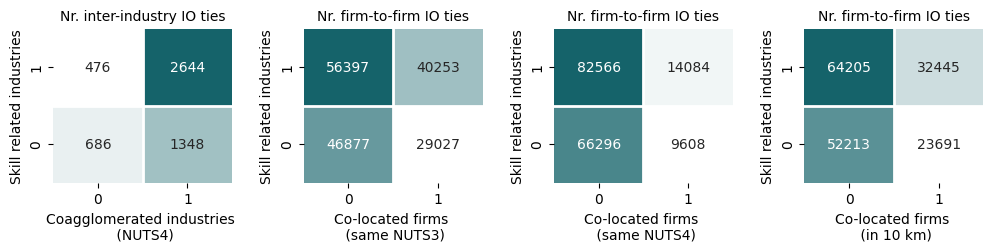

In [46]:
# crosstabs
fig, ax = plt.subplots(1,4, figsize=(12,2))
fontsize = 13
plt.subplots_adjust(wspace=0.4) 


# A-D -- column normalized matrices
crosstab_visual(
    ii_mat,
    fontsize=fontsize-3,
    colormap=cmap,
    title_text="Nr. inter-industry IO ties",
    axis_labels=["Coagglomerated industries \n (NUTS4)", "Skill related industries"],
    ax=ax[0]
)

crosstab_visual(
    ff_mat1,
    fontsize=fontsize-3,
    colormap=cmap,
    title_text="Nr. firm-to-firm IO ties",
    axis_labels=[f"Co-located firms \n (same NUTS3)", "Skill related industries"],
    ax=ax[1]
)

crosstab_visual(
    ff_mat2,
    fontsize=fontsize-3,
    colormap=cmap,
    title_text="Nr. firm-to-firm IO ties",
    axis_labels=["Co-located firms \n (same NUTS4)", "Skill related industries"],
    ax=ax[2]
)

crosstab_visual(
    ff_mat3,
    fontsize=fontsize-3,
    colormap=cmap,
    title_text="Nr. firm-to-firm IO ties",
    axis_labels=["Co-located firms \n (in 10 km)", "Skill related industries"],
    ax=ax[3]
)

#ax[0].annotate("A", xy=(0,1), xycoords='axes fraction', xytext=(-125,50), textcoords='offset pixels', weight='bold', size=fontsize)
#ax[1].annotate("B", xy=(0,1), xycoords='axes fraction', xytext=(-125,50), textcoords='offset pixels', weight='bold', size=fontsize)
#ax[2].annotate("C", xy=(0,1), xycoords='axes fraction', xytext=(-125,50), textcoords='offset pixels', weight='bold', size=fontsize)
#ax[3].annotate("D", xy=(0,1), xycoords='axes fraction', xytext=(-125,50), textcoords='offset pixels', weight='bold', size=fontsize)
#plt.savefig(f"../figures/si_crosstab_numbers.png", dpi=300, bbox_inches='tight', facecolor="white")